# 유저 탈퇴 분석

- 유저 탈퇴 테이블에는 **탈퇴 사유와 탈퇴 일시만 기록**되어 있어, 이탈한 사용자의 개별 특성이나 서비스 이용 행태를 직접적으로 파악하기에는 한계가 있습니다.

- 따라서 본 분석에서는 기록된 **탈퇴 사유와 시점에 나타나는 패턴을 탐색적으로 분석**하여, 사용자들이 어떤 이유로 서비스를 이탈하고 있는지 확인하고자 합니다.

- 이를 통해 서비스 이용 과정에서 발생할 수 있는 **불편 요소와 이탈에 영향을 미치는 요인을 간접적으로 파악**하고, 최종적으로 **사용자 이탈을 줄이기 위한 서비스 개선 방향을 도출하는 것**을 목표로 합니다.

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.cloud import bigquery

In [26]:
sns.set_theme(style="darkgrid")

plt.rc('font', family='AppleGothic')
# 마이너스 폰트 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [22]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_userwithdraw`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

      id       reason                created_at
0  69901  구독료가 너무 비싸서 2024-01-26 12:50:37+00:00
1  25824  구독료가 너무 비싸서 2023-05-15 10:37:40+00:00
2  44701  구독료가 너무 비싸서 2023-05-25 13:29:19+00:00
3  53418  구독료가 너무 비싸서 2023-06-15 08:15:47+00:00
4  23058  구독료가 너무 비싸서 2023-05-14 06:26:31+00:00


# 전체 데이터 비중 확인

In [28]:
reason_summary = (
    df['reason']
    .value_counts()
    .rename_axis('reason')
    .reset_index(name='count')
)

reason_summary['ratio'] = (
    reason_summary['count'] / reason_summary['count'].sum() * 100
).round(2)

reason_summary

,reason,count,ratio
0,기타,40019,56.94
1,함께 할 친구가 없어서,14393,20.48
2,재밌는 질문이 없어서,13109,18.65
3,버그가 너무 많아서,2030,2.89
4,구독료가 너무 비싸서,730,1.04


#### 💡 탈퇴 사유 분석

- 전체 탈퇴 사유 중 **`기타`가 56%로 가장 높은 비중**을 차지했습니다.

- 다만 `기타`는 사용자가 구체적인 사유를 선택하거나 작성하지 않고 탈퇴한 경우도 포함될 수 있어, **추가적인 정성 데이터 없이 실제 탈퇴 원인을 구체적으로 파악하기에는 한계**가 있습니다.

- 명확한 탈퇴 사유 중에서는 **`함께할 친구가 없어서`(20.48%)**, **`재밌는 질문이 없어서`(18.65%)**가 각각 두 번째와 세 번째로 높은 비중을 차지했습니다.

- 이는 일부 사용자가 서비스의 핵심 경험을 충분히 형성하지 못했거나, 서비스를 지속적으로 이용할 만큼의 **관계 형성 및 콘텐츠 측면의 가치를 느끼지 못했을 가능성**을 시사합니다.

- 따라서 초기 사용자에게 **함께 사용할 친구를 빠르게 확보할 수 있는 연결 구조**를 제공하고, 사용자의 흥미가 지속될 수 있도록 **질문 콘텐츠를 안정적으로 공급·갱신할 수 있는 시스템**을 강화할 필요가 있습니다.

# 월별 탈퇴 사유 분석

In [30]:
# 날짜 타입 변환
df['created_at'] = pd.to_datetime(df['created_at'])

# 탈퇴 월 생성
df['withdrawal_month'] = df['created_at'].dt.to_period('M').astype(str)

# 월별 탈퇴 사유 건수
monthly_reason = (
    df.groupby(['withdrawal_month', 'reason'])
      .size()
      .reset_index(name='count')
)

# 월별 전체 탈퇴자 대비 사유별 비중
monthly_reason['ratio'] = (
    monthly_reason['count']
    / monthly_reason.groupby('withdrawal_month')['count'].transform('sum')
    * 100
)

monthly_reason.head()

/var/folders/yd/3llw30vx5k3241gyl8_mwl_w0000gn/T/ipykernel_23821/4095291105.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['withdrawal_month'] = df['created_at'].dt.to_period('M').astype(str)


,withdrawal_month,reason,count,ratio
0,2023-03,기타,3,18.750000
1,2023-03,버그가 너무 많아서,2,12.500000
2,2023-03,재밌는 질문이 없어서,7,43.750000
3,2023-03,함께 할 친구가 없어서,4,25.000000
4,2023-04,구독료가 너무 비싸서,39,1.640724


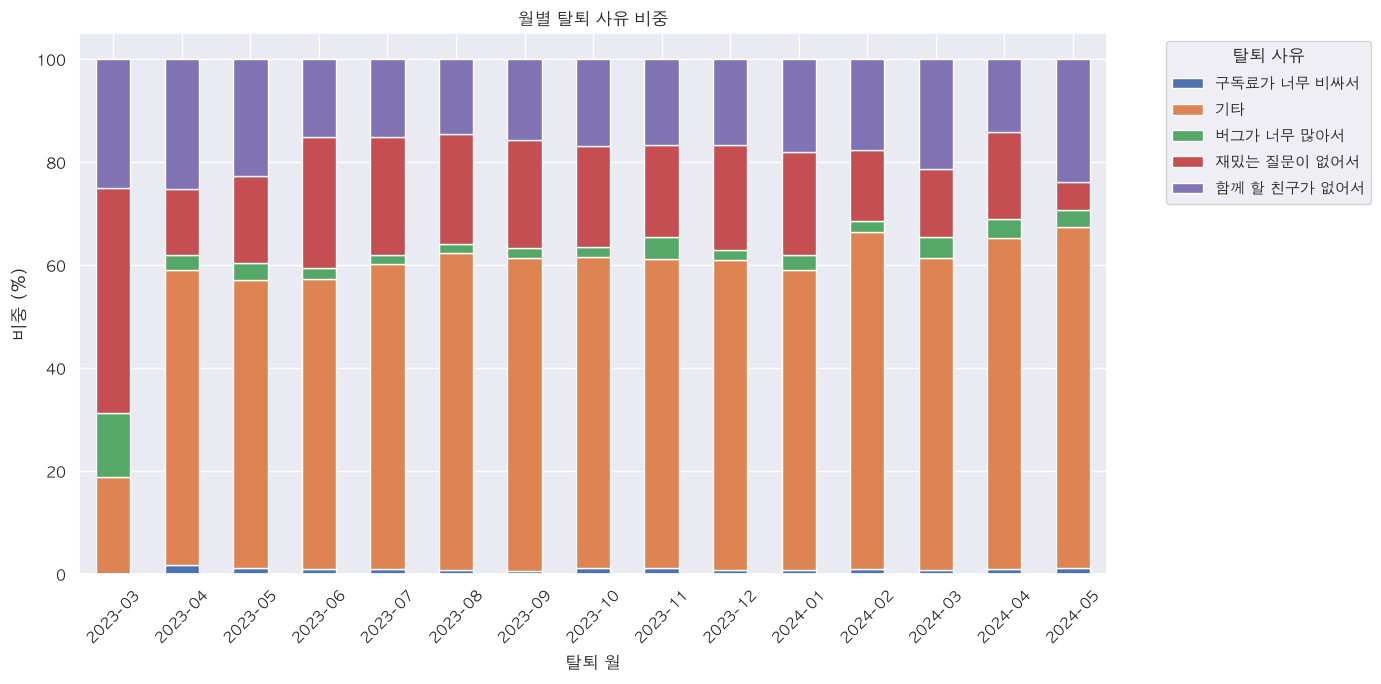

In [31]:
# 시각화용 pivot
reason_pivot = monthly_reason.pivot(
    index='withdrawal_month',
    columns='reason',
    values='ratio'
).fillna(0)

# 시각화
ax = reason_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.title('월별 탈퇴 사유 비중')
plt.xlabel('탈퇴 월')
plt.ylabel('비중 (%)')
plt.legend(
    title='탈퇴 사유',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# 시각화용 pivot
reason_pivot = monthly_reason.pivot(
    index='withdrawal_month',
    columns='reason',
    values='ratio'
).fillna(0)

reason_pivot

reason,구독료가 너무 비싸서,기타,버그가 너무 많아서,재밌는 질문이 없어서,함께 할 친구가 없어서
withdrawal_month,,,,,
2023-03,0.000000,18.750000,12.500000,43.750000,25.000000
2023-04,1.640724,57.425326,2.944889,12.663021,25.326041
2023-05,1.088839,56.016738,3.271018,16.816270,22.807136
2023-06,0.966435,56.302608,2.161488,25.418269,15.151200
2023-07,0.894901,59.229969,1.748179,22.955255,15.171696
2023-08,0.736888,61.551799,1.820546,21.239705,14.651062
2023-09,0.573535,60.671856,2.048341,21.015977,15.690291
2023-10,1.040763,60.450997,1.994796,19.514310,16.999133
2023-11,1.207729,60.024155,4.227053,17.753623,16.787440


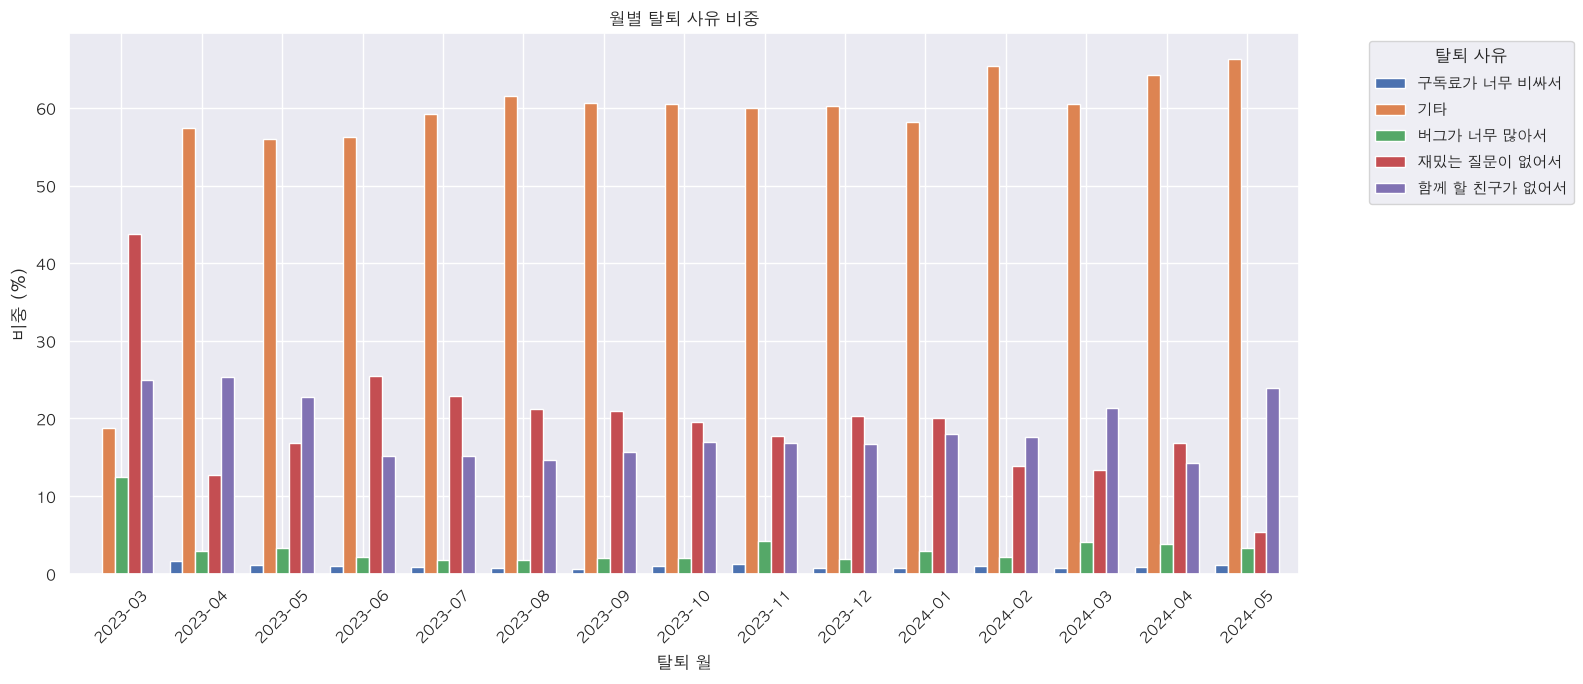

In [37]:
import matplotlib.pyplot as plt

ax = reason_pivot.plot(
    kind='bar',
    figsize=(16, 7),
    width=0.8
)

plt.title('월별 탈퇴 사유 비중')
plt.xlabel('탈퇴 월')
plt.ylabel('비중 (%)')

plt.legend(
    title='탈퇴 사유',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
# 시각화용 pivot
reason_pivot = monthly_reason.pivot(
    index='withdrawal_month',
    columns='reason',
    values='count'
).fillna(0)

reason_pivot

reason,구독료가 너무 비싸서,기타,버그가 너무 많아서,재밌는 질문이 없어서,함께 할 친구가 없어서
withdrawal_month,,,,,
2023-03,0.0,3.0,2.0,7.0,4.0
2023-04,39.0,1365.0,70.0,301.0,602.0
2023-05,484.0,24900.0,1454.0,7475.0,10138.0
2023-06,93.0,5418.0,208.0,2446.0,1458.0
2023-07,43.0,2846.0,84.0,1103.0,729.0
2023-08,17.0,1420.0,42.0,490.0,338.0
2023-09,14.0,1481.0,50.0,513.0,383.0
2023-10,12.0,697.0,23.0,225.0,196.0
2023-11,10.0,497.0,35.0,147.0,139.0


# 결론

- 전체 탈퇴 사유 중 `기타`가 가장 높은 비중을 차지했으나, 구체적인 원인을 파악하기 어렵다는 한계가 있습니다.

- `기타`를 제외하면 **친구 관계와 질문 콘텐츠가 사용자의 주요 이탈 요인으로 나타났습니다.** 이는 서비스의 핵심 경험을 구성하는 **관계 형성과 콘텐츠의 지속적인 흥미 제공**이 사용자 이탈과 밀접하게 연관되어 있을 가능성을 보여줍니다.

- 월별 추이를 확인한 결과, **질문 콘텐츠와 관련된 이탈 비중은 시간이 지나면서 다소 감소하는 흐름**을 보인 반면, **친구와 관련된 이탈 사유는 지속적으로 일정 비중을 차지**하고 있습니다.

- 따라서 질문 콘텐츠의 지속적인 개선과 함께, 특히 사용자가 서비스 내에서 **함께할 친구를 빠르게 확보하고 관계를 형성할 수 있도록 지원하는 방안**을 우선적으로 검토할 필요가 있습니다.